In [1]:
import torch
from torch import nn
from torchvision import datasets
from torchvision.transforms import transforms
from torch.utils.data.dataloader import DataLoader
import matplotlib.pyplot as plt

In [2]:
255/2

127.5

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
training = datasets.MNIST(
    root= "data",
    train = True,
    download = True,
    transform = transform
)


In [3]:
train_dataloader = DataLoader(training, 64, shuffle = True)

In [4]:
for x, _ in train_dataloader:
    print(x.min(), x.max())
    break

tensor(-1.) tensor(1.)


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

f'using {device}'

'using cpu'

In [8]:
class Descrimenator(nn.Module):
    def __init__(self):
        super(Descrimenator, self).__init__()
        self.fc1 = nn.Sequential(
            nn.Linear(28*28, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )
        self.fc2 = nn.Sequential(
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )
        self.fc3 = nn.Sequential(
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)

        )
        self.fc4 = nn.Sequential(
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, X):
        X = X.view(-1, 28*28)
        X = self.fc1(X)
        X = self.fc2(X)
        X = self.fc3(X)
        X = self.fc4(X)
        return X
descriminator = Descrimenator().to(device)    

In [5]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.fc1 = nn.Sequential(
            nn.Linear(128, 256),
            nn.LeakyReLU(0.2)
        )
        self.fc2 = nn.Sequential(
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2)
        )
        self.fc3 = nn.Sequential(
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2)
        )
        self.fc4 = nn.Sequential(
            nn.Linear(1024, 28*28),
            nn.Tanh()
        )
    def forward(self, X):
        X = self.fc1(X)
        X = self.fc2(X)
        X = self.fc3(X)
        X = self.fc4(X)
        X = X.view(-1, 1,28, 28)
        return X

generator = Generator().to(device)

In [7]:
def noise(size):
    return torch.randn(size, 128).to(device)
def ones(size):
    return torch.ones(size, 1).to(device)
def zeros(size):
    return torch.zeros(size, 1).to(device)

In [9]:
loss = nn.BCELoss()
optimizer_g = torch.optim.Adam(generator.parameters(), lr = 2e-4)
optimizer_d = torch.optim.Adam(descriminator.parameters(), lr = 2e-4)

In [10]:
def train_descriminator(real_data, fake_data, optim):
    size = real_data.shape[0]
    optim.zero_grad()
    dec = descriminator(real_data)
    dec_loss = loss(dec, ones(size))
    dec_loss.backward()

    gen = generator(fake_data)
    
    dec_gen = descriminator(gen)
    gen_loss = loss(dec_gen, zeros(size))
    gen_loss.backward()

    optim.step()
    return dec_loss + gen_loss

In [11]:
def train_generator(fake_data, optim):
    size = fake_data.shape[0]
    optim.zero_grad()
    gen = generator(fake_data)
    dec = descriminator(gen)
    gen_loss = loss(dec, ones(size))
    gen_loss.backward()
    optim.step()
    return gen_loss


In [12]:
num_epoch = 100
k = 1
#test_noise = noise(64).to(device)
generator.train()
descriminator.train()
for epoch in range(num_epoch):
    g_loss, d_loss = 0.0,0.0
    for idx,(X , _) in enumerate(train_dataloader):
        for i in range(k):
            real_data = X.to(device)
            fake_data = noise(X.shape[0])
            d_loss += train_descriminator(real_data, fake_data, optimizer_d)
        fake_data = noise(X.shape[0])
        g_loss += train_generator(fake_data, optimizer_g)
    print(f'Epoch :{epoch + 1}, g_loss : {g_loss / idx :.8f}, d_loss : {d_loss/ idx :.8f}')

Epoch :1, g_loss : 3.18868876, d_loss : 0.85970432
Epoch :2, g_loss : 1.69226527, d_loss : 0.99624395
Epoch :3, g_loss : 2.34246469, d_loss : 0.69689178
Epoch :4, g_loss : 2.64803410, d_loss : 0.56883472
Epoch :5, g_loss : 2.21619701, d_loss : 0.69162405
Epoch :6, g_loss : 2.12158227, d_loss : 0.67528051
Epoch :7, g_loss : 1.90920198, d_loss : 0.77924246
Epoch :8, g_loss : 1.82827854, d_loss : 0.81323183
Epoch :9, g_loss : 1.89080226, d_loss : 0.79381084
Epoch :10, g_loss : 1.88345361, d_loss : 0.81882399
Epoch :11, g_loss : 1.87326705, d_loss : 0.81864822
Epoch :12, g_loss : 1.64954007, d_loss : 0.89742714
Epoch :13, g_loss : 1.59213781, d_loss : 0.90509099
Epoch :14, g_loss : 1.51918328, d_loss : 0.94900906
Epoch :15, g_loss : 1.43599176, d_loss : 0.98034757
Epoch :16, g_loss : 1.50347793, d_loss : 0.95607644
Epoch :17, g_loss : 1.48988223, d_loss : 0.97028649
Epoch :18, g_loss : 1.44445252, d_loss : 0.98456818
Epoch :19, g_loss : 1.38422585, d_loss : 1.00468123
Epoch :20, g_loss : 1

In [13]:
torch.save(generator.state_dict(), 'generator.pth')
"save generator"

'save generator'

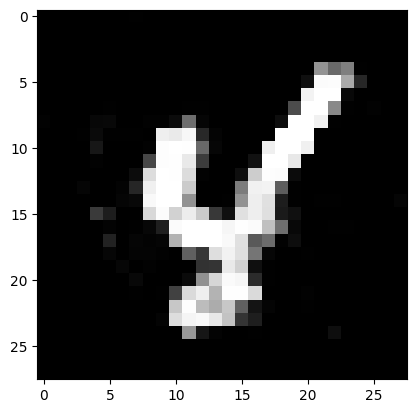

In [39]:
model = Generator()
model.load_state_dict(torch.load('models//generator.pth'))
model.eval()
gen = noise(1).to(device)
img = model(gen).cpu().detach().numpy()
img = img.reshape(28, 28)
plt.imshow(img, cmap = 'gray')